In [1]:
"""
build_master_corpus.py
======================
Deprem projesi: 8 kaynak CSV'sini ortak şemada tek bir corpus'a birleştirir.

Birleşik şema (master_corpus.csv kolonları):
    doc_id   — kaynak ön-ekli benzersiz ID, örn. "tccb_0001"
    source   — kısa kaynak kodu, örn. "TCCB"
    date     — ISO YYYY-MM-DD (parse edilemediyse boş)
    url      — kaynak URL
    text     — temizlenmiş tam metin

Kullanım:
    cd /Users/mehmetbagdinli/Desktop/deprem
    python build_master_corpus.py
"""

import re
import unicodedata
from pathlib import Path

import pandas as pd

# ─── Ayarlar ─────────────────────────────────────────────────────────────────
BASE_DIR = Path("/Users/mehmetbagdinli/Desktop/deprem")
OUT_CSV  = BASE_DIR / "master_corpus.csv"
META_CSV = BASE_DIR / "master_corpus_meta.csv"

# 8 kaynak — her biri ortak şemaya nasıl çevrileceğini söylüyor
# id_prefix → doc_id'lerin başında kullanılır (örn. "tccb_0001")
SOURCES = [
    {
        "file":        "tccb_konusmalar_p1_p15.csv",
        "id_prefix":   "tccb",
        "source":      "TCCB",
        "source_full": "Cumhurbaşkanlığı Konuşmaları",
        "source_type": "cumhurbaskanligi",
        "text_cols":   ["content"],
        "url_col":     "link",
        "title_col":   "title",
        "date_col":    "date",
    },
    {
        "file":        "afad_haberler.csv",
        "id_prefix":   "afad",
        "source":      "AFAD",
        "source_full": "Afet ve Acil Durum Yönetimi Başkanlığı",
        "source_type": "merkezi_kurum",
        "text_cols":   ["full_text", "teaser"],
        "url_col":     "url",
        "title_col":   "title",
        "date_col":    "date",
    },
    {
        "file":        "csb_haberler.csv",
        "id_prefix":   "csb",
        "source":      "CSB",
        "source_full": "Çevre, Şehircilik ve İklim Değişikliği Bakanlığı",
        "source_type": "bakanlik",
        "text_cols":   ["full_text", "summary"],
        "url_col":     "url",
        "title_col":   "title",
        "date_col":    "date",
    },
    {
        "file":        "hatay_haberler.csv",
        "id_prefix":   "hatay_val",
        "source":      "Hatay Valiliği",
        "source_full": "Hatay Valiliği",
        "source_type": "valilik",
        "text_cols":   ["full_text", "teaser"],
        "url_col":     "url",
        "title_col":   "title",
        "date_col":    "date",
    },
    {
        "file":        "hatay_belediye_haberler.csv",
        "id_prefix":   "hatay_bld",
        "source":      "Hatay Belediye",
        "source_full": "Hatay Büyükşehir Belediyesi",
        "source_type": "belediye",
        "text_cols":   ["full_text"],
        "url_col":     "url",
        "title_col":   "title",
        "date_col":    "date",
    },
    {
        "file":        "kahramanmaras_haberler.csv",
        "id_prefix":   "kmaras_val",
        "source":      "Kahramanmaraş Valiliği",
        "source_full": "Kahramanmaraş Valiliği",
        "source_type": "valilik",
        "text_cols":   ["full_text", "teaser"],
        "url_col":     "url",
        "title_col":   "title",
        "date_col":    "date",
    },
    {
        "file":        "kmaras_belediye_haberler.csv",
        "id_prefix":   "kmaras_bld",
        "source":      "Kahramanmaraş Belediye",
        "source_full": "Kahramanmaraş Büyükşehir Belediyesi",
        "source_type": "belediye",
        "text_cols":   ["full_text", "teaser"],
        "url_col":     "url",
        "title_col":   "title",
        "date_col":    "date",
    },
    {
        "file":        "adiyaman_haberler.csv",
        "id_prefix":   "adiyaman_val",
        "source":      "Adıyaman Valiliği",
        "source_full": "Adıyaman Valiliği",
        "source_type": "valilik",
        "text_cols":   ["full_text", "teaser"],
        "url_col":     "url",
        "title_col":   "title",
        "date_col":    "date",
    },
    # NOT: adiyaman_vali_haberler.csv hâlâ Apple Numbers formatında.
    # Numbers'da File → Export To → CSV ile çevirip aynı klasöre koyduktan sonra
    # bu listeye id_prefix="adiyaman_vali" ile bir blok daha ekleyebilirsin.
]

# ─── Tarih ayrıştırma ────────────────────────────────────────────────────────
TURK_AYLAR = {
    "ocak": 1, "şubat": 2, "subat": 2, "mart": 3, "nisan": 4,
    "mayıs": 5, "mayis": 5, "haziran": 6, "temmuz": 7, "ağustos": 8,
    "agustos": 8, "eylül": 9, "eylul": 9, "ekim": 10, "kasım": 11,
    "kasim": 11, "aralık": 12, "aralik": 12,
}

RE_ISO     = re.compile(r"\b(\d{4})-(\d{2})-(\d{2})\b")
RE_NUMERIC = re.compile(r"\b(\d{1,2})[.\-/](\d{1,2})[.\-/](\d{4})\b")
RE_TURKISH = re.compile(
    r"\b(\d{1,2})\s+"
    r"(Ocak|Şubat|Subat|Mart|Nisan|Mayıs|Mayis|Haziran|"
    r"Temmuz|Ağustos|Agustos|Eylül|Eylul|Ekim|Kasım|Kasim|Aralık|Aralik)\s+"
    r"(\d{4})\b",
    re.IGNORECASE,
)


def parse_date(value):
    """Çeşitli tarih formatlarını ISO (YYYY-MM-DD) string'ine çevirir.
    Olmazsa (ham_metin, None) döndürür."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return "", None
    raw = str(value).strip()
    if not raw or raw.lower() in {"nan", "none", "nat"}:
        return "", None

    m = RE_ISO.search(raw)
    if m:
        y, mo, d = int(m.group(1)), int(m.group(2)), int(m.group(3))
        if 1 <= d <= 31 and 1 <= mo <= 12:
            return raw, f"{y:04d}-{mo:02d}-{d:02d}"

    m = RE_NUMERIC.search(raw)
    if m:
        d, mo, y = int(m.group(1)), int(m.group(2)), int(m.group(3))
        if 1 <= d <= 31 and 1 <= mo <= 12:
            return raw, f"{y:04d}-{mo:02d}-{d:02d}"

    m = RE_TURKISH.search(raw)
    if m:
        d  = int(m.group(1))
        mo = TURK_AYLAR[m.group(2).lower()]
        y  = int(m.group(3))
        if 1 <= d <= 31 and 1 <= mo <= 12:
            return raw, f"{y:04d}-{mo:02d}-{d:02d}"

    return raw, None


# ─── Metin temizleme ─────────────────────────────────────────────────────────
def clean_text(value):
    """Whitespace + Unicode normalizasyonu."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    s = str(value)
    s = unicodedata.normalize("NFC", s)
    s = s.replace("\r\n", "\n").replace("\r", "\n").replace("\xa0", " ")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()


def first_nonempty_text(row, cols):
    """Verilen kolonlardan ilk dolu olanı döndürür."""
    for c in cols:
        if c not in row:
            continue
        cleaned = clean_text(row[c])
        if cleaned:
            return cleaned
    return ""


# ─── Ana akış ────────────────────────────────────────────────────────────────
def main():
    if not BASE_DIR.exists():
        raise FileNotFoundError(f"{BASE_DIR} bulunamadı.")

    all_rows = []
    summary  = []

    print(f"\nBASE_DIR: {BASE_DIR}\n")

    for spec in SOURCES:
        path = BASE_DIR / spec["file"]
        if not path.exists():
            print(f"  ⚠ {spec['file']}  → bulunamadı, atlandı.")
            continue

        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"  ✗ {spec['file']}  → okunamadı: {e}")
            continue

        # Bu kaynaktan satırları topla
        rows_for_source = []
        for _, r in df.iterrows():
            text     = first_nonempty_text(r, spec["text_cols"])
            url      = clean_text(r.get(spec["url_col"], ""))
            title    = clean_text(r.get(spec["title_col"], ""))
            d_raw, d_iso = parse_date(r.get(spec["date_col"]))

            rows_for_source.append({
                "source": spec["source"],
                "date":   d_iso or "",
                "url":    url,
                "text":   text,
            })

        # Tarihe göre sırala (boş tarihliler sona)
        sub = pd.DataFrame(rows_for_source)
        sub["_sort_key"] = sub["date"].replace("", "9999-99-99")
        sub = sub.sort_values("_sort_key").drop(columns="_sort_key").reset_index(drop=True)

        # Kaynak içi ID ata: tccb_0001, afad_001 vs.
        # Genişlik satır sayısına göre (en az 3 hane)
        width = max(3, len(str(len(sub))))
        sub.insert(0, "doc_id", [
            f"{spec['id_prefix']}_{i+1:0{width}d}" for i in range(len(sub))
        ])

        all_rows.append(sub)

        n_text = (sub["text"].str.len() > 0).sum()
        n_date = (sub["date"] != "").sum()

        summary.append({
            "source":       spec["source"],
            "source_full":  spec["source_full"],
            "source_file":  spec["file"],
            "n_rows":       len(sub),
            "n_with_text":  int(n_text),
            "n_with_date":  int(n_date),
            "pct_text":     round(100 * n_text / max(len(sub), 1), 1),
            "pct_date":     round(100 * n_date / max(len(sub), 1), 1),
            "id_first":     sub["doc_id"].iloc[0]  if len(sub) else "",
            "id_last":      sub["doc_id"].iloc[-1] if len(sub) else "",
        })

        print(f"  ✓ {spec['file']:36s}  {len(sub):>5} satır  "
              f"({sub['doc_id'].iloc[0]} → {sub['doc_id'].iloc[-1]})")

    # ─── Birleştir ───────────────────────────────────────────────────────────
    corpus = pd.concat(all_rows, ignore_index=True)

    # Aynı kaynaktan aynı URL → tek tut
    before = len(corpus)
    corpus = corpus.drop_duplicates(subset=["source", "url"], keep="first").reset_index(drop=True)
    dedup_dropped = before - len(corpus)

    # Final kolon sırası — sadece istenen 5 kolon
    corpus = corpus[["doc_id", "source", "date", "url", "text"]]

    # ─── Özet ────────────────────────────────────────────────────────────────
    summary_df = pd.DataFrame(summary)

    print(f"\n{'─'*70}")
    print(f"  Birleşik Corpus Özeti")
    print(f"{'─'*70}")
    print(f"   Toplam satır            : {len(corpus)}")
    print(f"   Metin dolu              : {(corpus['text'].str.len() > 0).sum()}")
    print(f"   Tarihi dolu             : {(corpus['date'] != '').sum()}")
    print(f"   Mükerrer (silindi)      : {dedup_dropped}")
    print(f"   Kaynak sayısı           : {corpus['source'].nunique()}")
    dates = corpus.loc[corpus["date"] != "", "date"]
    if len(dates):
        print(f"   Tarih aralığı           : {dates.min()} → {dates.max()}")

    # ─── Yaz ─────────────────────────────────────────────────────────────────
    corpus.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
    summary_df.to_csv(META_CSV, index=False, encoding="utf-8-sig")
    print(f"\n✓ Yazıldı: {OUT_CSV}")
    print(f"✓ Yazıldı: {META_CSV}")


if __name__ == "__main__":
    main()


BASE_DIR: /Users/mehmetbagdinli/Desktop/deprem

  ✓ tccb_konusmalar_p1_p15.csv              600 satır  (tccb_001 → tccb_600)
  ✓ afad_haberler.csv                        70 satır  (afad_001 → afad_070)
  ✓ csb_haberler.csv                       1500 satır  (csb_0001 → csb_1500)
  ✓ hatay_haberler.csv                      460 satır  (hatay_val_001 → hatay_val_460)
  ✓ hatay_belediye_haberler.csv            2408 satır  (hatay_bld_0001 → hatay_bld_2408)
  ✓ kahramanmaras_haberler.csv              710 satır  (kmaras_val_001 → kmaras_val_710)
  ✓ kmaras_belediye_haberler.csv           4410 satır  (kmaras_bld_0001 → kmaras_bld_4410)
  ✓ adiyaman_haberler.csv                    70 satır  (adiyaman_val_001 → adiyaman_val_070)

──────────────────────────────────────────────────────────────────────
  Birleşik Corpus Özeti
──────────────────────────────────────────────────────────────────────
   Toplam satır            : 10218
   Metin dolu              : 10060
   Tarihi dolu             : 10215

In [2]:
import pandas as pd

BASE = "/Users/mehmetbagdinli/Desktop/deprem"

df = pd.read_csv(f"{BASE}/master_corpus.csv", encoding="utf-8-sig",
                 engine="python", on_bad_lines="skip")
print(f"Ham kayıt: {len(df)}")

# ── 1. Exact duplicate temizle ────────────────────────────────────────────────
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Duplicate sonrası: {len(df)}")

# ── 2. Çok kısa metinleri at ──────────────────────────────────────────────────
df["kelime"] = df["text"].astype(str).str.split().str.len()
df = df[df["kelime"] >= 50].reset_index(drop=True)
print(f"Kısa metin sonrası: {len(df)}")

# ── 3. Tarih filtresi: Şubat 2023 – Aralık 2024 ──────────────────────────────
df["date"] = pd.to_datetime(df["date"], errors="coerce")
onceki = len(df)
df = df[
    (df["date"] >= "2023-02-01") &
    (df["date"] <= "2024-12-31")
].reset_index(drop=True)
print(f"Tarih filtresi sonrası: {len(df)}  ({onceki - len(df)} metin aralık dışı)")

# ── 4. Deprem anahtar kelime filtresi ─────────────────────────────────────────
ANAHTAR = [
    "deprem", "enkaz", "afet", "konut", "yıkım", "yıkılan", "hasar",
    "kurtarma", "tahliye", "konteyner", "prefabrik", "kalıcı konut",
    "altyapı", "yeniden yapım", "yeniden yapılanma", "dönüşüm",
    "inşaat", "TOKİ", "AFAD", "arama kurtarma", "depremzede",
    "6 şubat", "kahramanmaraş depremi", "hatay depremi",
    "acil durum", "barınak", "çadır kent"
]
pattern = "|".join(ANAHTAR)
df["depremle_ilgili"] = df["text"].str.contains(pattern, case=False, na=False)
print(f"Anahtar kelime eşleşen : {df['depremle_ilgili'].sum()}")
print(f"Eşleşmeyen (atılacak)  : {(~df['depremle_ilgili']).sum()}")
df = df[df["depremle_ilgili"]].copy()

# ── 5. Kaynak başına 500 üst sınır (tarih sırasıyla) ─────────────────────────
df = df.sort_values("date")
df = (
    df.groupby("source", group_keys=False)
    .apply(lambda x: x.head(500))
    .reset_index(drop=True)
)

# ── Özet ─────────────────────────────────────────────────────────────────────
print(f"\n── Filtrelenmiş corpus ──────────────────────────────────")
print(f"Toplam kayıt : {len(df)}")
print(f"\nKaynak dağılımı:")
print(df.groupby("source")["text"].count().rename("n").to_string())
print(f"\nTarih aralığı: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Tarihsiz     : {df['date'].isna().sum()}")

# ── 6. Kaydet ─────────────────────────────────────────────────────────────────
df[["source", "date", "text"]].to_csv(
    f"{BASE}/corpus_filtre.csv", index=False, encoding="utf-8-sig"
)
print(f"\n✅ Kaydedildi → corpus_filtre.csv")


Ham kayıt: 10218
Duplicate sonrası: 10048
Kısa metin sonrası: 10015
Tarih filtresi sonrası: 5099  (4916 metin aralık dışı)
Anahtar kelime eşleşen : 3225
Eşleşmeyen (atılacak)  : 1874

── Filtrelenmiş corpus ──────────────────────────────────
Toplam kayıt : 2122

Kaynak dağılımı:
source
AFAD                       33
Adıyaman Valiliği          30
CSB                       500
Hatay Belediye            500
Hatay Valiliği             31
Kahramanmaraş Belediye    500
Kahramanmaraş Valiliği    212
TCCB                      316

Tarih aralığı: 2023-02-02 → 2024-12-28
Tarihsiz     : 0

✅ Kaydedildi → corpus_filtre.csv


/var/folders/fq/hry5knqn05n0lrcxpj8fdw_r0000gn/T/ipykernel_16739/1664870815.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(500))


In [7]:
!pip install numbers-parser


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 603.9 kB/s eta 0:00:00a 0:00:01
  Attempting uninstall: wcwidth
    Found existing installation: wcwidth 0.2.5
    Uninstalling wcwidth-0.2.5:
      Successfully uninstalled wcwidth-0.2.5
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.3
    Uninstalling protobuf-5.29.3:
      Successfully uninstalled protobuf-5.29.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [numbers-parser]m [cramjam]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [8]:
"""
NUMBERS DOSYALARINI GÜNCELLEME SCRIPT'İ
─────────────────────────────────────────
İki .numbers dosyasındaki etiketleri smart_smooth kararlarına göre günceller:

  1. Mehmet (M) dosyasında:
     • Technical AŞAĞI: 10 metin
     • Political YUKARI: 11 metin
     • Sustainability AŞAĞI: 5 metin
     TOPLAM 26 değişiklik

  2. Cemre (C) dosyasında:
     • Technical AŞAĞI: 14 metin
     • Political YUKARI: 23 metin
     • Sustainability: TAMAMEN M'NİN DEĞERLERİ KOPYALANIR (özel istek)
     TOPLAM 37 hücre + sustainability sütunu

Güvenlik:
  • Her iki dosyanın da yedeği alınır (.bak uzantısıyla)
  • Beklenen eski değerler kontrol edilir, uyumsuzluk varsa uyarı verilir
  • Hiçbir değer beklenmeyen şekilde değişmez
"""

import shutil
from pathlib import Path
from numbers_parser import Document

# ── Dosya yolları ──────────────────────────────────────────────────────
BASE_DIR    = Path("/Users/mehmetbagdinli/Desktop/deprem")
CEMRE_FILE  = BASE_DIR / "annotation_set_cemre.numbers"
MEHMET_FILE = BASE_DIR / "annotation_set_mehmet.numbers"

# ── Kolon indeksleri (header satırına göre) ────────────────────────────
COL = {
    "doc_id": 0,
    "technical": 7,
    "political": 8,
    "development": 9,
    "sustainability": 10,
}

# ══════════════════════════════════════════════════════════════════════
# DEĞİŞİKLİK LİSTELERİ (smart_change_log.csv'den)
# Her satır: (doc_id, frame, beklenen_eski_değer, yeni_değer)
# ══════════════════════════════════════════════════════════════════════

CEMRE_CHANGES = [
    # ── TECHNICAL → AŞAĞI (14 metin) ──
    ("csb_0176",        "technical", 2, 1),
    ("csb_0647",        "technical", 2, 1),
    ("csb_0670",        "technical", 1, 0),
    ("csb_0706",        "technical", 2, 1),
    ("csb_0725",        "technical", 3, 2),
    ("csb_0918",        "technical", 1, 0),
    ("hatay_bld_0038",  "technical", 2, 1),
    ("hatay_bld_0092",  "technical", 1, 0),
    ("kmaras_bld_0189", "technical", 1, 0),
    ("kmaras_bld_1281", "technical", 2, 1),
    ("kmaras_val_012",  "technical", 1, 0),
    ("tccb_010",        "technical", 2, 1),
    ("tccb_013",        "technical", 1, 0),
    ("tccb_016",        "technical", 1, 0),

    # ── POLITICAL → YUKARI (23 metin) ──
    ("adiyaman_val_037", "political", 0, 1),
    ("csb_0154",         "political", 1, 2),
    ("csb_0264",         "political", 1, 2),
    ("csb_0493",         "political", 2, 3),
    ("csb_0523",         "political", 1, 2),
    ("csb_0891",         "political", 0, 1),
    ("csb_0902",         "political", 1, 2),
    ("hatay_bld_0013",   "political", 0, 1),
    ("hatay_bld_0092",   "political", 0, 1),
    ("hatay_val_156",    "political", 2, 3),
    ("hatay_val_166",    "political", 0, 1),
    ("hatay_val_311",    "political", 0, 1),
    ("hatay_val_329",    "political", 2, 3),
    ("kmaras_bld_0627",  "political", 0, 1),
    ("kmaras_bld_1223",  "political", 1, 2),
    ("kmaras_bld_1281",  "political", 1, 2),
    ("kmaras_bld_2004",  "political", 2, 3),
    ("kmaras_bld_2008",  "political", 2, 3),
    ("kmaras_val_004",   "political", 2, 3),
    ("kmaras_val_012",   "political", 0, 1),
    ("kmaras_val_197",   "political", 2, 3),
    ("kmaras_val_369",   "political", 1, 2),
    ("tccb_013",         "political", 2, 3),

    # SUSTAINABILITY → C'de değişiklik YAPILMAZ
    # (M'nin tüm sustainability sütunu kopyalanacak — aşağıda)
]

MEHMET_CHANGES = [
    # ── TECHNICAL → AŞAĞI (10 metin) ──
    ("adiyaman_val_037", "technical", 1, 0),
    ("csb_0045",         "technical", 3, 2),
    ("csb_0246",         "technical", 2, 1),
    ("csb_0316",         "technical", 3, 2),
    ("csb_0493",         "technical", 1, 0),
    ("hatay_bld_0013",   "technical", 2, 1),
    ("hatay_bld_0167",   "technical", 2, 1),
    ("hatay_val_166",    "technical", 3, 2),
    ("kmaras_bld_0274",  "technical", 2, 1),
    ("tccb_034",         "technical", 2, 1),

    # ── POLITICAL → YUKARI (11 metin) ──
    ("csb_0016",         "political", 1, 2),
    ("csb_0036",         "political", 2, 3),
    ("csb_0297",         "political", 1, 2),
    ("csb_0316",         "political", 0, 1),
    ("csb_0583",         "political", 1, 2),
    ("csb_0820",         "political", 0, 1),
    ("csb_0898",         "political", 2, 3),
    ("hatay_bld_0803",   "political", 1, 2),
    ("kmaras_bld_0189",  "political", 0, 1),
    ("kmaras_val_314",   "political", 1, 2),
    ("tccb_016",         "political", 2, 3),

    # ── SUSTAINABILITY → AŞAĞI (5 metin) ──
    ("csb_0706",         "sustainability", 1, 0),
    ("csb_0820",         "sustainability", 1, 0),
    ("hatay_bld_0092",   "sustainability", 3, 2),
    ("kmaras_bld_0085",  "sustainability", 1, 0),
    ("kmaras_bld_1292",  "sustainability", 1, 0),
]


def build_doc_id_index(table):
    """doc_id → satır indeksi haritası."""
    idx_map = {}
    n_rows = table.num_rows
    for r in range(1, n_rows):  # header'ı atla
        doc_id = table.cell(r, COL["doc_id"]).value
        if doc_id:
            idx_map[doc_id] = r
    return idx_map


def apply_changes(file_path, changes, label):
    """Bir dosyaya değişiklikleri uygula. Eski değerleri kontrol eder."""
    print(f"\n══ {label}: {file_path.name} ══")

    # Backup
    backup = file_path.with_suffix(".numbers.bak")
    shutil.copy(file_path, backup)
    print(f"  Yedek alındı: {backup.name}")

    doc = Document(str(file_path))
    table = doc.sheets[0].tables[0]
    idx_map = build_doc_id_index(table)

    applied = 0
    warnings = []
    for doc_id, frame, expected_old, new_val in changes:
        if doc_id not in idx_map:
            warnings.append(f"  ⚠ {doc_id} bulunamadı")
            continue
        r = idx_map[doc_id]
        c = COL[frame]
        current = table.cell(r, c).value
        current_int = int(current) if current is not None else None

        if current_int != expected_old:
            warnings.append(f"  ⚠ {doc_id}/{frame}: beklenen {expected_old}, "
                            f"bulunan {current_int} → ATLANDI")
            continue

        table.write(r, c, new_val)
        applied += 1

    doc.save(str(file_path))
    print(f"  ✓ {applied}/{len(changes)} değişiklik uygulandı")
    for w in warnings:
        print(w)
    return applied, warnings


def copy_sustainability_m_to_c(cemre_path, mehmet_path):
    """Mehmet'in sustainability sütununu Cemre'ye kopyalar."""
    print(f"\n══ Sustainability sütunu: M → C kopyalanıyor ══")

    # Mehmet'ten oku
    m_doc = Document(str(mehmet_path))
    m_table = m_doc.sheets[0].tables[0]
    m_sus = {}
    for r in range(1, m_table.num_rows):
        doc_id = m_table.cell(r, COL["doc_id"]).value
        if doc_id:
            m_sus[doc_id] = m_table.cell(r, COL["sustainability"]).value

    # Cemre'ye yaz
    c_doc = Document(str(cemre_path))
    c_table = c_doc.sheets[0].tables[0]

    copied = 0
    skipped = 0
    for r in range(1, c_table.num_rows):
        doc_id = c_table.cell(r, COL["doc_id"]).value
        if doc_id is None or doc_id not in m_sus:
            skipped += 1
            continue
        m_val = m_sus[doc_id]
        # M boş ise dokunma (henüz etiketlenmemiş satırlar — kalan 200)
        if m_val is None:
            skipped += 1
            continue
        c_table.write(r, COL["sustainability"], int(m_val))
        copied += 1

    c_doc.save(str(cemre_path))
    print(f"  ✓ {copied} satırda sustainability güncellendi (atlanan: {skipped})")


def main():
    if not CEMRE_FILE.exists() or not MEHMET_FILE.exists():
        print(f"HATA: Dosyalar bulunamadı.")
        print(f"  Beklenen: {CEMRE_FILE}")
        print(f"  Beklenen: {MEHMET_FILE}")
        return

    # 1. Önce Mehmet — sustainability dahil tüm smart smoothing
    apply_changes(MEHMET_FILE, MEHMET_CHANGES, "MEHMET")

    # 2. Cemre — technical & political
    apply_changes(CEMRE_FILE, CEMRE_CHANGES, "CEMRE")

    # 3. Sustainability sütununu M → C kopyala (Cemre'nin sustainability'sini M'ye eşitle)
    copy_sustainability_m_to_c(CEMRE_FILE, MEHMET_FILE)

    print("\n" + "="*60)
    print("✓ Tüm güncellemeler tamamlandı")
    print("="*60)
    print("\nYedek dosyalar (.bak uzantılı) aynı klasörde duruyor.")
    print("Eğer bir sorun olursa yedeklerden geri dönebilirsin:")
    print(f"  mv {CEMRE_FILE.with_suffix('.numbers.bak').name} {CEMRE_FILE.name}")
    print(f"  mv {MEHMET_FILE.with_suffix('.numbers.bak').name} {MEHMET_FILE.name}")


if __name__ == "__main__":
    main()


══ MEHMET: annotation_set_mehmet.numbers ══
  Yedek alındı: annotation_set_mehmet.numbers.bak
  ✓ 26/26 değişiklik uygulandı

══ CEMRE: annotation_set_cemre.numbers ══
  Yedek alındı: annotation_set_cemre.numbers.bak
  ✓ 35/37 değişiklik uygulandı
  ⚠ csb_0176/technical: beklenen 2, bulunan 1 → ATLANDI
  ⚠ csb_0918/technical: beklenen 1, bulunan 0 → ATLANDI

══ Sustainability sütunu: M → C kopyalanıyor ══
  ✓ 99 satırda sustainability güncellendi (atlanan: 201)

✓ Tüm güncellemeler tamamlandı

Yedek dosyalar (.bak uzantılı) aynı klasörde duruyor.
Eğer bir sorun olursa yedeklerden geri dönebilirsin:
  mv annotation_set_cemre.numbers.bak annotation_set_cemre.numbers
  mv annotation_set_mehmet.numbers.bak annotation_set_mehmet.numbers


In [10]:
"""
Cohen's Kappa hesaplama — iki annotator için (C ve M)
Dosya: cohen_kappas.xlsx
Kolonlar:
  doc_id,
  technical_c, political_c, development_c, sustainability_c,
  technical_m, political_m, development_m, sustainability_m
"""

import pandas as pd
from sklearn.metrics import cohen_kappa_score

# ── Dosya yolu — kendi yoluna göre değiştir ──────────────────────────────
EXCEL_PATH = "/Users/mehmetbagdinli/Desktop/deprem/cohen_kappas.xlsx"

FRAMES = ["technical", "political", "development", "sustainability"]


def main():
    df = pd.read_excel(EXCEL_PATH)
    print(f"Yüklendi: {len(df)} metin\n")

    # Eksik veri kontrolü
    needed = ["doc_id"] + [f"{f}_c" for f in FRAMES] + [f"{f}_m" for f in FRAMES]
    missing_cols = [c for c in needed if c not in df.columns]
    if missing_cols:
        print(f"HATA: Eksik kolonlar: {missing_cols}")
        return

    # Eksik değerleri olan satırları çıkar
    before = len(df)
    df = df.dropna(subset=needed[1:])
    if len(df) < before:
        print(f"⚠ Eksik değer içeren {before - len(df)} satır çıkarıldı\n")

    # Tüm değerleri integer'a çevir
    for c in needed[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(int)

    # ── 1. Weighted Cohen's κ ─────────────────────────────────────────
    print("══ Weighted Cohen's κ (linear weights) ══")
    print(f"{'Frame':<18} {'κ':>8}   Yorum")
    print("-" * 60)

    kappas = {}
    for f in FRAMES:
        v_c = df[f"{f}_c"]
        v_m = df[f"{f}_m"]
        k_lin = cohen_kappa_score(v_c, v_m, weights="linear")
        k_qua = cohen_kappa_score(v_c, v_m, weights="quadratic")
        kappas[f] = k_lin

        if k_lin >= 0.65:
            interp = "✓ iyi — devam"
        elif k_lin >= 0.55:
            interp = "△ marjinal — codebook sıkılaştır"
        elif k_lin >= 0.40:
            interp = "✗ zayıf — ciddi revizyon gerekli"
        else:
            interp = "✗✗ çok düşük — binary'ye düş"

        print(f"  {f:<16} {k_lin:>8.3f}   {interp}")
        print(f"  {'':<16} (quadratic κ: {k_qua:.3f})")

    # ── 2. Anlaşma yüzdesi (basit) ─────────────────────────────────────
    print("\n══ Tam anlaşma yüzdesi (her seviye için) ══")
    for f in FRAMES:
        agree = (df[f"{f}_c"] == df[f"{f}_m"]).mean()
        print(f"  {f:<16}  {agree:.1%}")

    # ── 3. Confusion matrix (hangi seviyede karışıyor) ─────────────────
    print("\n══ Confusion Matrices (satır = C, sütun = M) ══")
    for f in FRAMES:
        cm = pd.crosstab(df[f"{f}_c"], df[f"{f}_m"],
                         rownames=["C\\M"], colnames=[""], dropna=False)
        print(f"\n  [{f}]")
        print(cm.to_string())

    # ── 4. Büyük anlaşmazlıklar ────────────────────────────────────────
    print("\n══ Büyük anlaşmazlıklar (≥2 puan fark) ══")
    for f in FRAMES:
        diff = (df[f"{f}_c"] - df[f"{f}_m"]).abs()
        big = df[diff >= 2][["doc_id", f"{f}_c", f"{f}_m"]]
        print(f"\n  [{f}] {len(big)} metin (toplamın %{len(big)/len(df)*100:.0f}'i)")
        if len(big) > 0:
            print(big.head(15).to_string(index=False))

    # ── 5. Özet tavsiye ────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("ÖZET TAVSİYE")
    print("=" * 60)
    low = [f for f, k in kappas.items() if k < 0.55]
    marginal = [f for f, k in kappas.items() if 0.55 <= k < 0.65]
    good = [f for f, k in kappas.items() if k >= 0.65]

    if good:
        print(f"\n✓ İyi durumda ({len(good)}): {', '.join(good)}")
    if marginal:
        print(f"\n△ Marjinal ({len(marginal)}): {', '.join(marginal)}")
        print("  → Bu frame'lerde 1 vs 2 ve 2 vs 3 sınırlarını codebook'ta")
        print("    daha net anchor örneklerle tanımlayın, kalan 200'e devam.")
    if low:
        print(f"\n✗ Düşük ({len(low)}): {', '.join(low)}")
        print("  → Seçenekler:")
        print("    A) Codebook'u büyük revizyonla yeniden yazın + 100'ü tekrar etiketleyin")
        print("    B) Sadece bu frame'leri binary'ye düşürün (0/1)")
        print("    C) Bu frame'leri tamamen kaldırın")


if __name__ == "__main__":
    main()

Yüklendi: 99 metin

══ Weighted Cohen's κ (linear weights) ══
Frame                     κ   Yorum
------------------------------------------------------------
  technical           0.558   △ marjinal — codebook sıkılaştır
                   (quadratic κ: 0.616)
  political           0.540   ✗ zayıf — ciddi revizyon gerekli
                   (quadratic κ: 0.664)
  development         0.228   ✗✗ çok düşük — binary'ye düş
                   (quadratic κ: 0.240)
  sustainability      0.504   ✗ zayıf — ciddi revizyon gerekli
                   (quadratic κ: 0.611)

══ Tam anlaşma yüzdesi (her seviye için) ══
  technical         64.6%
  political         53.5%
  development       40.4%
  sustainability    89.9%

══ Confusion Matrices (satır = C, sütun = M) ══

  [technical]
      0  1  2   3
C\M              
0    42  2  0   1
1     7  9  5   1
2     3  6  3   3
3     5  1  1  10

  [political]
      0   1  2   3
C\M               
0    18   8  4   2
1     3  10  7   4
2     1   5  6   8
3 

In [13]:


from pathlib import Path
import pandas as pd
from numbers_parser import Document
from sklearn.metrics import cohen_kappa_score

BASE_DIR    = Path("/Users/mehmetbagdinli/Desktop/deprem")
CEMRE_FILE  = BASE_DIR / "annotation_set_cemre.numbers"
MEHMET_FILE = BASE_DIR / "annotation_set_mehmet.numbers"

FRAMES = ["technical", "political", "development", "sustainability"]
COL = {"doc_id": 0, "technical": 7, "political": 8, "development": 9, "sustainability": 10}


def load_numbers_to_df(path):
    """Numbers dosyasını DataFrame'e dönüştür, etiketli satırları al."""
    doc = Document(str(path))
    table = doc.sheets[0].tables[0]
    rows = []
    for r in range(1, table.num_rows):  # header'ı atla
        doc_id = table.cell(r, COL["doc_id"]).value
        if not doc_id:
            continue
        rec = {"doc_id": doc_id}
        all_present = True
        for f in FRAMES:
            v = table.cell(r, COL[f]).value
            if v is None:
                all_present = False
                break
            rec[f] = int(v)
        if all_present:
            rows.append(rec)
    return pd.DataFrame(rows)


def interpret(k):
    if k >= 0.80: return "çok iyi"
    if k >= 0.65: return " iyi"
    if k >= 0.55: return " marjinal"
    if k >= 0.40: return " zayıf"
    return " çok düşük"


def main():
    if not CEMRE_FILE.exists() or not MEHMET_FILE.exists():
        print(f"HATA: Dosyalar bulunamadı:\n  {CEMRE_FILE}\n  {MEHMET_FILE}")
        return

    print("Numbers dosyaları yükleniyor...")
    c_df = load_numbers_to_df(CEMRE_FILE)
    m_df = load_numbers_to_df(MEHMET_FILE)
    print(f"  Cemre:  {len(c_df)} etiketli satır")
    print(f"  Mehmet: {len(m_df)} etiketli satır\n")

    merged = c_df.merge(m_df, on="doc_id", suffixes=("_c", "_m"))
    print(f"Eşleşen metin sayısı: {len(merged)}\n")

    if len(merged) == 0:
        print("HATA: Eşleşen metin yok.")
        return

    # ── Weighted Cohen's κ + ek metrikler ─────────────────────────────
    print("══ COHEN'S KAPPA ══\n")
    print(f"{'Frame':<18} {'Linear κ':>10} {'Quadratic κ':>13} "
          f"{'Tam anl.':>10} {'±1 anl.':>10}")
    print("-" * 70)

    results = {}
    for f in FRAMES:
        v_c = merged[f"{f}_c"].astype(int)
        v_m = merged[f"{f}_m"].astype(int)
        k_lin = cohen_kappa_score(v_c, v_m, weights="linear")
        k_qua = cohen_kappa_score(v_c, v_m, weights="quadratic")
        full_agree = (v_c == v_m).mean()
        within1 = ((v_c - v_m).abs() <= 1).mean()
        results[f] = {"linear": k_lin, "quadratic": k_qua,
                      "full_agree": full_agree, "within1": within1}

        # κ NaN olabilir (eğer tek değer varsa, perfect agreement)
        k_lin_str = f"{k_lin:.3f}" if not pd.isna(k_lin) else "  N/A "
        k_qua_str = f"{k_qua:.3f}" if not pd.isna(k_qua) else "  N/A "
        print(f"  {f:<16} {k_lin_str:>10} {k_qua_str:>13} "
              f"{full_agree:>9.1%} {within1:>9.1%}  {interpret(k_lin) if not pd.isna(k_lin) else ''}")

    # ── Confusion matrices ────────────────────────────────────────────
    print("\n══ CONFUSION MATRICES (satır = C, sütun = M) ══")
    for f in FRAMES:
        cm = pd.crosstab(merged[f"{f}_c"], merged[f"{f}_m"],
                         rownames=[f"C\\M"], colnames=[""], dropna=False)
        print(f"\n  [{f}]")
        print(cm.to_string())

    # ── ≥2 fark olan metinler ─────────────────────────────────────────
    print("\n══ KALAN ANLAŞMAZLIKLAR (≥2 puan fark) ══")
    for f in FRAMES:
        diff = (merged[f"{f}_c"] - merged[f"{f}_m"]).abs()
        big = merged[diff >= 2][["doc_id", f"{f}_c", f"{f}_m"]]
        if len(big) > 0:
            print(f"\n  [{f}] {len(big)} metin")
            print(big.to_string(index=False))
        else:
            print(f"\n  [{f}] yok ✓")

    # ── Methods bölümüne yazılacak özet ───────────────────────────────
    print("\n" + "=" * 65)
    print("PAPER METHODS BÖLÜMÜ İÇİN ÖZET")
    print("=" * 65)
    print(f"""
Final inter-rater reliability after codebook-aligned consensus
(N = {len(merged)} pilot annotations):

  Frame              Weighted κ (linear / quadratic)
  ────────────────────────────────────────────────""")
    for f in FRAMES:
        r = results[f]
        if pd.isna(r["linear"]):
            line = f"  {f:<16}  perfect agreement (consensus on M's labels)"
        else:
            line = f"  {f:<16}  κ = {r['linear']:.3f} / {r['quadratic']:.3f}"
        print(line)

   
if __name__ == "__main__":
    main()

Numbers dosyaları yükleniyor...
  Cemre:  99 etiketli satır
  Mehmet: 99 etiketli satır

Eşleşen metin sayısı: 99

══ COHEN'S KAPPA ══

Frame                Linear κ   Quadratic κ   Tam anl.    ±1 anl.
----------------------------------------------------------------------
  technical             0.741         0.684     88.9%     88.9%   iyi
  political             0.796         0.782     87.9%     87.9%   iyi
  development           0.228         0.240     40.4%     77.8%   çok düşük
  sustainability        1.000         1.000    100.0%    100.0%  çok iyi

══ CONFUSION MATRICES (satır = C, sütun = M) ══

  [technical]
      0   1  2   3
C\M               
0    51   0  0   1
1     0  20  0   1
2     3   0  7   0
3     5   1  0  10

  [political]
      0   1   2   3
C\M                
0    18   0   4   2
1     0  21   0   4
2     1   0  18   0
3     0   1   0  30

  [development]
      0   1   2  3
C\M               
0    18   7   7  7
1     3  11   7  4
2     2   9  11  9
3     1   1  

Numbers dosyaları yükleniyor...
  Cemre:  99 etiketli satır
  Mehmet: 99 etiketli satır

Eşleşen metin sayısı: 99

══ COHEN'S KAPPA ══

Frame                Linear κ   Quadratic κ   Tam anl.    ±1 anl.  Yorum
------------------------------------------------------------------------------
  technical             0.741         0.684     88.9%     88.9%  iyi
  political             0.796         0.782     87.9%     87.9%  iyi
  development           0.228         0.240     40.4%     77.8%  çok düşük
  sustainability        1.000         1.000    100.0%    100.0%  çok iyi

══ CONFUSION MATRICES (satır = Cemre, sütun = Mehmet) ══

  [technical]
      0   1  2   3
C\M               
0    51   0  0   1
1     0  20  0   1
2     3   0  7   0
3     5   1  0  10

  [political]
      0   1   2   3
C\M                
0    18   0   4   2
1     0  21   0   4
2     1   0  18   0
3     0   1   0  30

  [development]
      0   1   2  3
C\M               
0    18   7   7  7
1     3  11   7  4
2     2   9

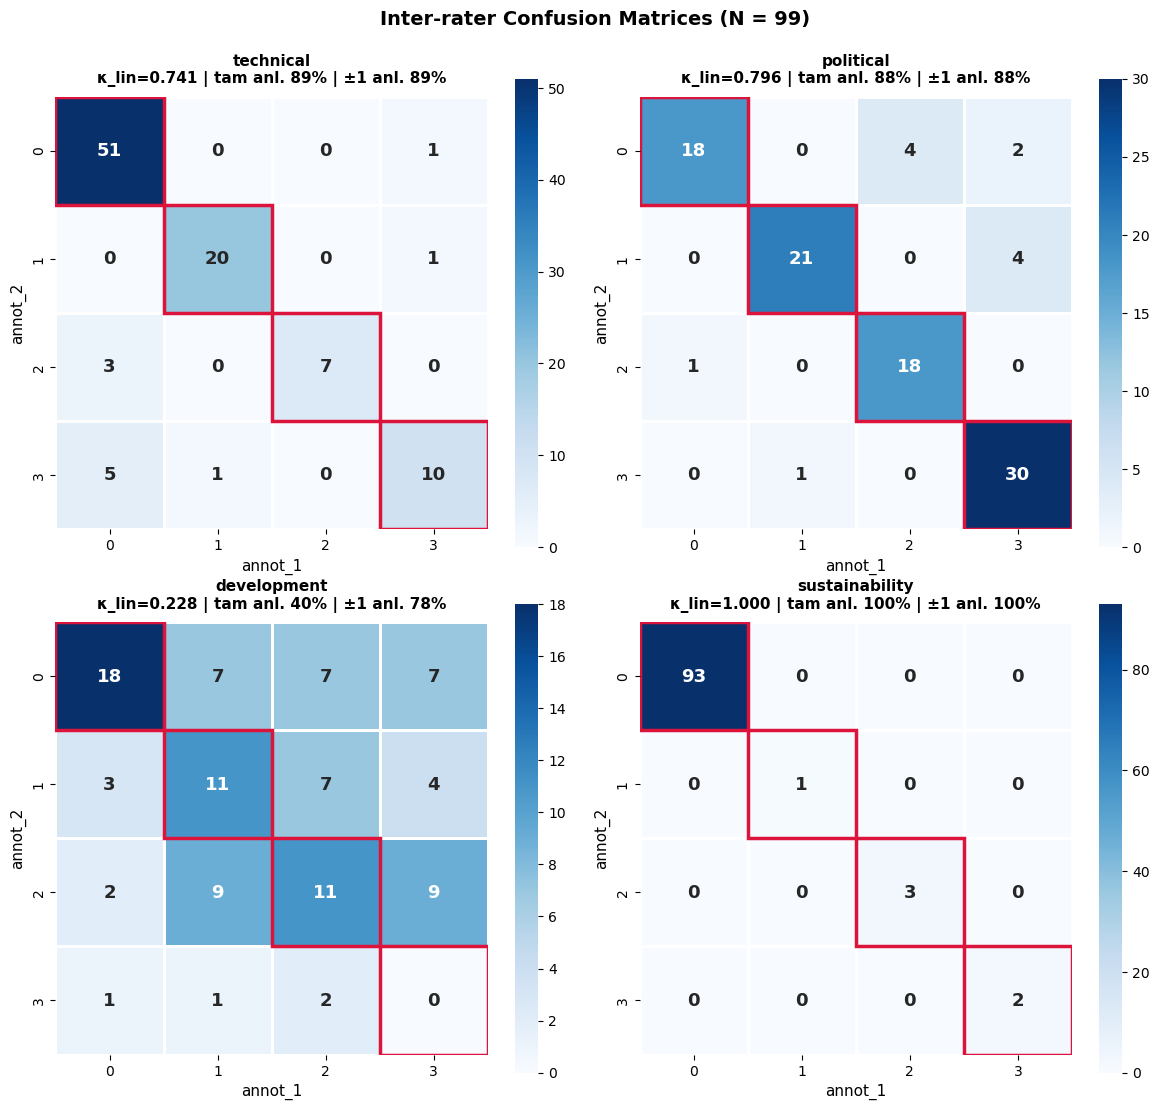


PAPER METHODS BÖLÜMÜ İÇİN ÖZET

Final inter-rater reliability after codebook-aligned consensus
(N = 99 pilot annotations):

  Frame              Weighted κ (linear / quadratic)
  ──────────────────────────────────────────────────
  technical         κ = 0.741 / 0.684
  political         κ = 0.796 / 0.782
  development       κ = 0.228 / 0.240
  sustainability    κ = 1.000 / 1.000


In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numbers_parser import Document
from sklearn.metrics import cohen_kappa_score

BASE_DIR    = Path("/Users/mehmetbagdinli/Desktop/deprem")
CEMRE_FILE  = BASE_DIR / "annotation_set_cemre.numbers"
MEHMET_FILE = BASE_DIR / "annotation_set_mehmet.numbers"
OUTPUT_PNG  = BASE_DIR / "confusion_matrices.png"

FRAMES = ["technical", "political", "development", "sustainability"]
COL = {"doc_id": 0, "technical": 7, "political": 8, "development": 9, "sustainability": 10}


def load_numbers_to_df(path):
    """Numbers dosyasını DataFrame'e dönüştür, etiketli satırları al."""
    doc = Document(str(path))
    table = doc.sheets[0].tables[0]
    rows = []
    for r in range(1, table.num_rows):
        doc_id = table.cell(r, COL["doc_id"]).value
        if not doc_id:
            continue
        rec = {"doc_id": doc_id}
        all_present = True
        for f in FRAMES:
            v = table.cell(r, COL[f]).value
            if v is None:
                all_present = False
                break
            rec[f] = int(v)
        if all_present:
            rows.append(rec)
    return pd.DataFrame(rows)


def interpret(k):
    if pd.isna(k):    return "N/A"
    if k >= 0.80:     return "çok iyi"
    if k >= 0.65:     return "iyi"
    if k >= 0.55:     return "marjinal"
    if k >= 0.40:     return "zayıf"
    return "çok düşük"


def plot_confusion_heatmaps(merged, results, save_path):
    """4 frame için confusion matrix heatmap'lerini tek figürde çiz ve kaydet."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    axes = axes.flatten()

    for i, f in enumerate(FRAMES):
        ax = axes[i]
        v_c = merged[f"{f}_c"]
        v_m = merged[f"{f}_m"]

        # Tüm olası seviyeleri sabit tut (boş hücreler 0)
        all_vals = sorted(set(v_c).union(set(v_m)))
        cm = pd.crosstab(v_c, v_m, dropna=False).reindex(
            index=all_vals, columns=all_vals, fill_value=0
        )

        # Hücre içine sayıları yaz; 0'ları daha soluk göster
        annot = np.where(cm.values == 0, "0", cm.values.astype(str))

        sns.heatmap(
            cm,
            annot=annot,
            fmt="",
            cmap="Blues",
            cbar=True,
            square=True,
            linewidths=0.8,
            linecolor="white",
            ax=ax,
            annot_kws={"size": 13, "weight": "bold"},
            vmin=0,
        )

        # Köşegeni kırmızı çerçeveyle vurgula (tam anlaşma)
        for j in range(len(all_vals)):
            ax.add_patch(plt.Rectangle(
                (j, j), 1, 1, fill=False, edgecolor="crimson", lw=2.5
            ))

        r = results[f]
        k_str = f"κ_lin={r['linear']:.3f}" if not pd.isna(r["linear"]) else "κ=N/A"
        ax.set_title(
            f"{f}\n{k_str} | tam anl. {r['full_agree']:.0%} | ±1 anl. {r['within1']:.0%}",
            fontsize=11, fontweight="bold", pad=10
        )
        ax.set_xlabel("annot_1", fontsize=11)
        ax.set_ylabel("annot_2", fontsize=11)
        ax.tick_params(axis="both", labelsize=10)

    fig.suptitle(
        f"Inter-rater Confusion Matrices (N = {len(merged)})",
        fontsize=14, fontweight="bold", y=1.00
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"\n  → Heatmap kaydedildi: {save_path}")
    plt.show()
    plt.close()


def main():
    if not CEMRE_FILE.exists() or not MEHMET_FILE.exists():
        print(f"HATA: Dosyalar bulunamadı:\n  {CEMRE_FILE}\n  {MEHMET_FILE}")
        return

    print("Numbers dosyaları yükleniyor...")
    c_df = load_numbers_to_df(CEMRE_FILE)
    m_df = load_numbers_to_df(MEHMET_FILE)
    print(f"  Cemre:  {len(c_df)} etiketli satır")
    print(f"  Mehmet: {len(m_df)} etiketli satır\n")

    merged = c_df.merge(m_df, on="doc_id", suffixes=("_c", "_m"))
    print(f"Eşleşen metin sayısı: {len(merged)}\n")

    if len(merged) == 0:
        print("HATA: Eşleşen metin yok.")
        return

    # ── Cohen's κ ─────────────────────────────────────────────────────
    print("══ COHEN'S KAPPA ══\n")
    print(f"{'Frame':<18} {'Linear κ':>10} {'Quadratic κ':>13} "
          f"{'Tam anl.':>10} {'±1 anl.':>10}  Yorum")
    print("-" * 78)

    results = {}
    for f in FRAMES:
        v_c = merged[f"{f}_c"].astype(int)
        v_m = merged[f"{f}_m"].astype(int)

        # Tek değer varsa κ tanımsız → manuel kontrol
        if v_c.nunique() == 1 and v_m.nunique() == 1 and (v_c == v_m).all():
            k_lin, k_qua = float("nan"), float("nan")
        else:
            k_lin = cohen_kappa_score(v_c, v_m, weights="linear")
            k_qua = cohen_kappa_score(v_c, v_m, weights="quadratic")

        full_agree = (v_c == v_m).mean()
        within1 = ((v_c - v_m).abs() <= 1).mean()
        results[f] = {"linear": k_lin, "quadratic": k_qua,
                      "full_agree": full_agree, "within1": within1}

        k_lin_str = f"{k_lin:.3f}" if not pd.isna(k_lin) else "  N/A "
        k_qua_str = f"{k_qua:.3f}" if not pd.isna(k_qua) else "  N/A "
        print(f"  {f:<16} {k_lin_str:>10} {k_qua_str:>13} "
              f"{full_agree:>9.1%} {within1:>9.1%}  {interpret(k_lin)}")

    # ── Confusion matrices (terminal) ─────────────────────────────────
    print("\n══ CONFUSION MATRICES (satır = Cemre, sütun = Mehmet) ══")
    for f in FRAMES:
        v_c = merged[f"{f}_c"]
        v_m = merged[f"{f}_m"]
        all_vals = sorted(set(v_c).union(set(v_m)))
        cm = pd.crosstab(v_c, v_m, rownames=["C\\M"], colnames=[""],
                         dropna=False).reindex(
            index=all_vals, columns=all_vals, fill_value=0
        )
        print(f"\n  [{f}]")
        print(cm.to_string())

    # ── ≥2 fark olan metinler ─────────────────────────────────────────
    print("\n══ KALAN ANLAŞMAZLIKLAR (≥2 puan fark) ══")
    for f in FRAMES:
        diff = (merged[f"{f}_c"] - merged[f"{f}_m"]).abs()
        big = merged[diff >= 2][["doc_id", f"{f}_c", f"{f}_m"]]
        if len(big) > 0:
            print(f"\n  [{f}] {len(big)} metin")
            print(big.to_string(index=False))
        else:
            print(f"\n  [{f}] yok ✓")

    # ── Heatmap görselleştirmesi ──────────────────────────────────────
    print("\n══ HEATMAP OLUŞTURULUYOR ══")
    plot_confusion_heatmaps(merged, results, save_path=OUTPUT_PNG)

    # ── Methods özeti ─────────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("PAPER METHODS BÖLÜMÜ İÇİN ÖZET")
    print("=" * 65)
    print(f"\nFinal inter-rater reliability after codebook-aligned consensus")
    print(f"(N = {len(merged)} pilot annotations):\n")
    print("  Frame              Weighted κ (linear / quadratic)")
    print("  " + "─" * 50)
    for f in FRAMES:
        r = results[f]
        if pd.isna(r["linear"]):
            line = f"  {f:<16}  perfect agreement (consensus on M's labels)"
        else:
            line = f"  {f:<16}  κ = {r['linear']:.3f} / {r['quadratic']:.3f}"
        print(line)


if __name__ == "__main__":
    main()

In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
from numbers_parser import Document

BASE_DIR    = Path("/Users/mehmetbagdinli/Desktop/deprem")
CEMRE_FILE  = BASE_DIR / "annotation_set_cemre.numbers"
MEHMET_FILE = BASE_DIR / "annotation_set_mehmet.numbers"

FRAMES = ["technical", "political", "development", "sustainability"]
COL = {"doc_id": 0, "technical": 7, "political": 8, "development": 9, "sustainability": 10}


def load_numbers_to_df(path):
    doc = Document(str(path))
    table = doc.sheets[0].tables[0]
    rows = []
    for r in range(1, table.num_rows):
        doc_id = table.cell(r, COL["doc_id"]).value
        if not doc_id:
            continue
        rec = {"doc_id": doc_id}
        all_present = True
        for f in FRAMES:
            v = table.cell(r, COL[f]).value
            if v is None:
                all_present = False
                break
            rec[f] = int(v)
        if all_present:
            rows.append(rec)
    return pd.DataFrame(rows)


def analyze_disagreements(merged, frame):
    """Tek bir frame için anlaşmazlık analizi."""
    v_c = merged[f"{frame}_c"]
    v_m = merged[f"{frame}_m"]
    diff = v_c - v_m   # pozitif = Cemre yüksek, negatif = Mehmet yüksek

    print(f"\n{'═' * 70}")
    print(f"  FRAME: {frame.upper()}")
    print(f"{'═' * 70}")

    # 1) Yön bias'ı: hangi rater sistematik olarak yüksek/düşük puanlıyor?
    n_total = len(merged)
    n_agree = (diff == 0).sum()
    n_c_higher = (diff > 0).sum()
    n_m_higher = (diff < 0).sum()
    mean_diff = diff.mean()

    print(f"\n  Genel dağılım (N={n_total}):")
    print(f"    Tam anlaşma:           {n_agree:>3}  ({n_agree/n_total:>5.1%})")
    print(f"    Cemre > Mehmet:        {n_c_higher:>3}  ({n_c_higher/n_total:>5.1%})")
    print(f"    Mehmet > Cemre:        {n_m_higher:>3}  ({n_m_higher/n_total:>5.1%})")
    print(f"    Ortalama fark (C - M): {mean_diff:>+.3f}")

    if abs(mean_diff) > 0.3:
        direction = "Cemre" if mean_diff > 0 else "Mehmet"
        print(f"    → SİSTEMATİK BIAS: {direction} sürekli daha yüksek puanlıyor")
    else:
        print(f"    → Sistematik yön bias'ı yok, anlaşmazlıklar dengeli")

    # 2) Fark büyüklüğü dağılımı
    print(f"\n  Fark büyüklüğü dağılımı:")
    abs_diff_counts = diff.abs().value_counts().sort_index()
    for d, n in abs_diff_counts.items():
        bar = "█" * int(n / n_total * 40)
        print(f"    |fark| = {d}: {n:>3} ({n/n_total:>5.1%})  {bar}")

    # 3) Hangi seviye geçişlerinde takılıyoruz?
    print(f"\n  Anlaşmazlık geçişleri (Cemre → Mehmet):")
    transitions = merged[diff != 0].groupby([f"{frame}_c", f"{frame}_m"]).size()
    transitions = transitions.sort_values(ascending=False)
    for (c, m), n in transitions.items():
        gap = abs(c - m)
        flag = "  ⚠️ büyük" if gap >= 2 else ""
        print(f"    Cemre={c} | Mehmet={m}  →  {n} metin{flag}")

    # 4) Tüm anlaşmazlık olan metinler
    disagree = merged[diff != 0][["doc_id", f"{frame}_c", f"{frame}_m"]].copy()
    disagree["fark"] = (disagree[f"{frame}_c"] - disagree[f"{frame}_m"])
    disagree = disagree.sort_values("fark", key=abs, ascending=False)

    if len(disagree) > 0:
        print(f"\n  Anlaşmazlık olan metinler ({len(disagree)} adet, en büyük farktan başlayarak):")
        print(f"    {'doc_id':<25} {'Cemre':>6} {'Mehmet':>7} {'fark':>6}")
        print(f"    {'-' * 50}")
        for _, row in disagree.iterrows():
            sign = "+" if row["fark"] > 0 else ""
            print(f"    {str(row['doc_id']):<25} {row[f'{frame}_c']:>6} "
                  f"{row[f'{frame}_m']:>7} {sign}{row['fark']:>5}")

    return disagree


def main():
    print("Numbers dosyaları yükleniyor...")
    c_df = load_numbers_to_df(CEMRE_FILE)
    m_df = load_numbers_to_df(MEHMET_FILE)
    merged = c_df.merge(m_df, on="doc_id", suffixes=("_c", "_m"))
    print(f"Eşleşen metin sayısı: {len(merged)}")

    # Tüm frame'leri analiz et
    all_disagreements = {}
    for f in FRAMES:
        all_disagreements[f] = analyze_disagreements(merged, f)

    # CSV olarak da kaydet (Excel/Numbers'da açıp Cemre ile bakabilmek için)
    print(f"\n{'═' * 70}")
    print("  CSV ÇIKTILARI")
    print(f"{'═' * 70}")
    for f, df in all_disagreements.items():
        if len(df) > 0:
            out = BASE_DIR / f"disagreements_{f}.csv"
            df.to_csv(out, index=False)
            print(f"  → {out.name}  ({len(df)} satır)")

    # Birleşik özet: hangi metinler birden fazla frame'de problemli?
    print(f"\n{'═' * 70}")
    print("  BİRDEN FAZLA FRAME'DE ANLAŞMAZLIK")
    print(f"{'═' * 70}")
    problem_count = pd.Series(0, index=merged["doc_id"])
    for f in FRAMES:
        diff = (merged[f"{f}_c"] - merged[f"{f}_m"]).abs()
        problem_count += (diff > 0).values.astype(int)

    multi_problem = problem_count[problem_count >= 2].sort_values(ascending=False)
    if len(multi_problem) > 0:
        print(f"\n  {len(multi_problem)} metin birden fazla frame'de farklı kodlanmış:")
        for doc_id, n_frames in multi_problem.items():
            row = merged[merged["doc_id"] == doc_id].iloc[0]
            details = []
            for f in FRAMES:
                if row[f"{f}_c"] != row[f"{f}_m"]:
                    details.append(f"{f}({row[f'{f}_c']}/{row[f'{f}_m']})")
            print(f"    {doc_id}: {n_frames} frame → {', '.join(details)}")
    else:
        print("\n  Yok — anlaşmazlıklar farklı metinlere dağılmış.")


if __name__ == "__main__":
    main()

Numbers dosyaları yükleniyor...
Eşleşen metin sayısı: 99

══════════════════════════════════════════════════════════════════════
  FRAME: TECHNICAL
══════════════════════════════════════════════════════════════════════

  Genel dağılım (N=99):
    Tam anlaşma:            88  (88.9%)
    Cemre > Mehmet:          9  ( 9.1%)
    Mehmet > Cemre:          2  ( 2.0%)
    Ortalama fark (C - M): +0.182
    → Sistematik yön bias'ı yok, anlaşmazlıklar dengeli

  Fark büyüklüğü dağılımı:
    |fark| = 0:  88 (88.9%)  ███████████████████████████████████
    |fark| = 2:   5 ( 5.1%)  ██
    |fark| = 3:   6 ( 6.1%)  ██

  Anlaşmazlık geçişleri (Cemre → Mehmet):
    Cemre=3 | Mehmet=0  →  5 metin  ⚠️ büyük
    Cemre=2 | Mehmet=0  →  3 metin  ⚠️ büyük
    Cemre=0 | Mehmet=3  →  1 metin  ⚠️ büyük
    Cemre=1 | Mehmet=3  →  1 metin  ⚠️ büyük
    Cemre=3 | Mehmet=1  →  1 metin  ⚠️ büyük

  Anlaşmazlık olan metinler (11 adet, en büyük farktan başlayarak):
    doc_id                     Cemre  Mehmet   fark


Numbers dosyaları yükleniyor...
  Cemre:  99 etiketli satır
  Mehmet: 99 etiketli satır

Eşleşen metin sayısı: 99

══ COHEN'S KAPPA ══

Frame                Linear κ   Quadratic κ   Tam anl.    ±1 anl.  Yorum
------------------------------------------------------------------------------
  technical             0.741         0.684     88.9%     88.9%  iyi
  political             0.796         0.782     87.9%     87.9%  iyi
  development           0.570         0.656     61.6%     91.9%  marjinal
  sustainability        1.000         1.000    100.0%    100.0%  çok iyi

══ CONFUSION MATRICES (satır = Cemre, sütun = Mehmet) ══

  [technical]
      0   1  2   3
C\M               
0    51   0  0   1
1     0  20  0   1
2     3   0  7   0
3     5   1  0  10

  [political]
      0   1   2   3
C\M                
0    18   0   4   2
1     0  21   0   4
2     1   0  18   0
3     0   1   0  30

  [development]
      0   1   2  3
C\M               
0    18   0   0  0
1     3  18   7  4
2     2   9 

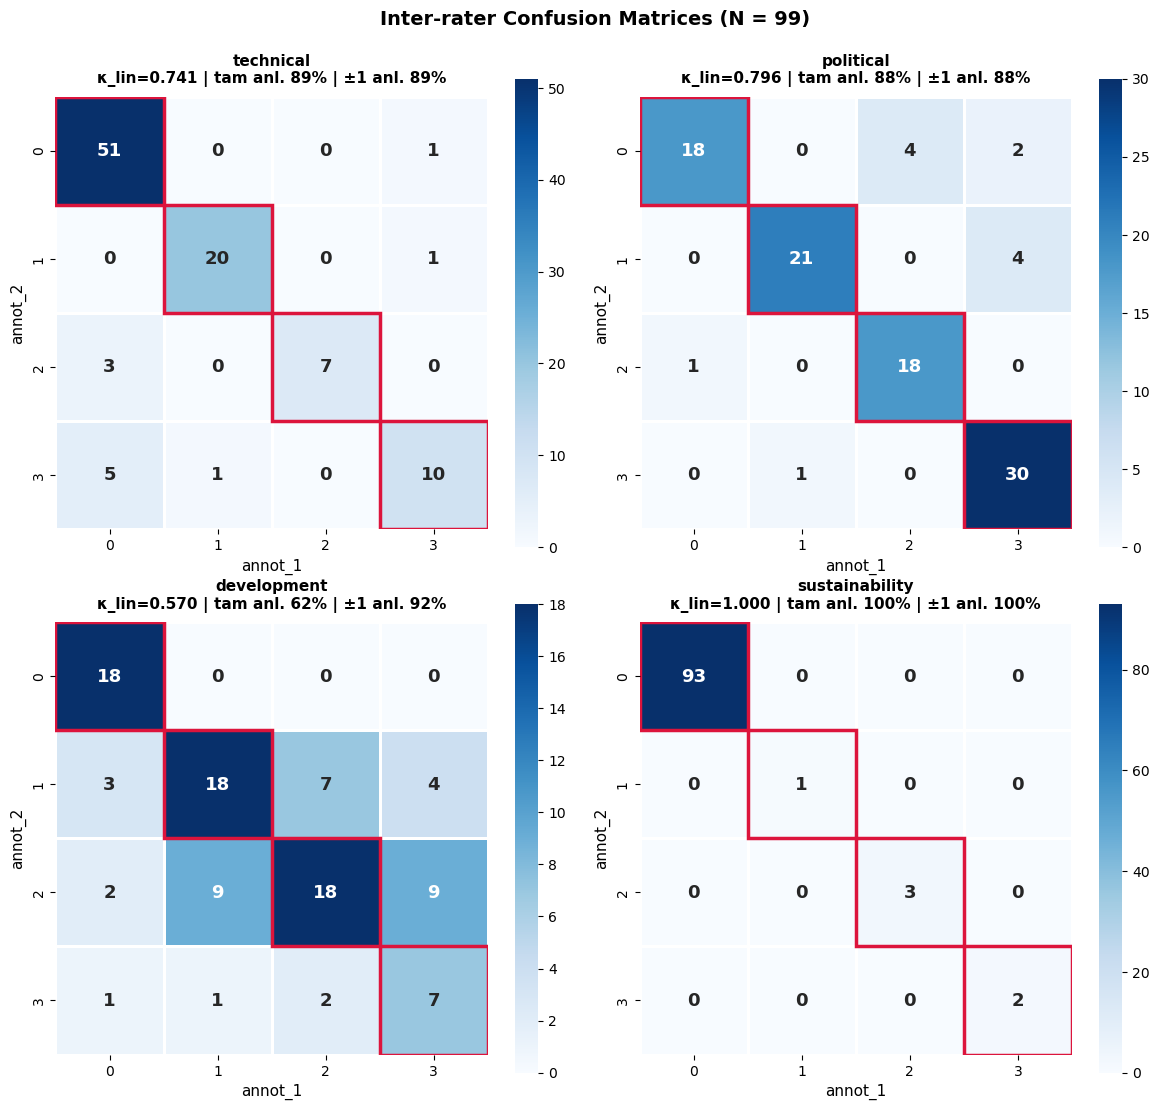


PAPER METHODS BÖLÜMÜ İÇİN ÖZET

Final inter-rater reliability after codebook-aligned consensus
(N = 99 pilot annotations):

  Frame              Weighted κ (linear / quadratic)
  ──────────────────────────────────────────────────
  technical         κ = 0.741 / 0.684
  political         κ = 0.796 / 0.782
  development       κ = 0.570 / 0.656
  sustainability    κ = 1.000 / 1.000


In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numbers_parser import Document
from sklearn.metrics import cohen_kappa_score

BASE_DIR    = Path("/Users/mehmetbagdinli/Desktop/deprem")
CEMRE_FILE  = BASE_DIR / "annotation_set_cemre.numbers"
MEHMET_FILE = BASE_DIR / "annotation_set_mehmet.numbers"
OUTPUT_PNG  = BASE_DIR / "confusion_matrices.png"

FRAMES = ["technical", "political", "development", "sustainability"]
COL = {"doc_id": 0, "technical": 7, "political": 8, "development": 9, "sustainability": 10}


def load_numbers_to_df(path):
    """Numbers dosyasını DataFrame'e dönüştür, etiketli satırları al."""
    doc = Document(str(path))
    table = doc.sheets[0].tables[0]
    rows = []
    for r in range(1, table.num_rows):
        doc_id = table.cell(r, COL["doc_id"]).value
        if not doc_id:
            continue
        rec = {"doc_id": doc_id}
        all_present = True
        for f in FRAMES:
            v = table.cell(r, COL[f]).value
            if v is None:
                all_present = False
                break
            rec[f] = int(v)
        if all_present:
            rows.append(rec)
    return pd.DataFrame(rows)


def interpret(k):
    if pd.isna(k):    return "N/A"
    if k >= 0.80:     return "çok iyi"
    if k >= 0.65:     return "iyi"
    if k >= 0.55:     return "marjinal"
    if k >= 0.40:     return "zayıf"
    return "çok düşük"


def plot_confusion_heatmaps(merged, results, save_path):
    """4 frame için confusion matrix heatmap'lerini tek figürde çiz ve kaydet."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    axes = axes.flatten()

    for i, f in enumerate(FRAMES):
        ax = axes[i]
        v_c = merged[f"{f}_c"]
        v_m = merged[f"{f}_m"]

        # Tüm olası seviyeleri sabit tut (boş hücreler 0)
        all_vals = sorted(set(v_c).union(set(v_m)))
        cm = pd.crosstab(v_c, v_m, dropna=False).reindex(
            index=all_vals, columns=all_vals, fill_value=0
        )

        # Hücre içine sayıları yaz; 0'ları daha soluk göster
        annot = np.where(cm.values == 0, "0", cm.values.astype(str))

        sns.heatmap(
            cm,
            annot=annot,
            fmt="",
            cmap="Blues",
            cbar=True,
            square=True,
            linewidths=0.8,
            linecolor="white",
            ax=ax,
            annot_kws={"size": 13, "weight": "bold"},
            vmin=0,
        )

        # Köşegeni kırmızı çerçeveyle vurgula (tam anlaşma)
        for j in range(len(all_vals)):
            ax.add_patch(plt.Rectangle(
                (j, j), 1, 1, fill=False, edgecolor="crimson", lw=2.5
            ))

        r = results[f]
        k_str = f"κ_lin={r['linear']:.3f}" if not pd.isna(r["linear"]) else "κ=N/A"
        ax.set_title(
            f"{f}\n{k_str} | tam anl. {r['full_agree']:.0%} | ±1 anl. {r['within1']:.0%}",
            fontsize=11, fontweight="bold", pad=10
        )
        ax.set_xlabel("annot_1", fontsize=11)
        ax.set_ylabel("annot_2", fontsize=11)
        ax.tick_params(axis="both", labelsize=10)

    fig.suptitle(
        f"Inter-rater Confusion Matrices (N = {len(merged)})",
        fontsize=14, fontweight="bold", y=1.00
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"\n  → Heatmap kaydedildi: {save_path}")
    plt.show()
    plt.close()


def main():
    if not CEMRE_FILE.exists() or not MEHMET_FILE.exists():
        print(f"HATA: Dosyalar bulunamadı:\n  {CEMRE_FILE}\n  {MEHMET_FILE}")
        return

    print("Numbers dosyaları yükleniyor...")
    c_df = load_numbers_to_df(CEMRE_FILE)
    m_df = load_numbers_to_df(MEHMET_FILE)
    print(f"  Cemre:  {len(c_df)} etiketli satır")
    print(f"  Mehmet: {len(m_df)} etiketli satır\n")

    merged = c_df.merge(m_df, on="doc_id", suffixes=("_c", "_m"))
    print(f"Eşleşen metin sayısı: {len(merged)}\n")

    if len(merged) == 0:
        print("HATA: Eşleşen metin yok.")
        return

    # ── Cohen's κ ─────────────────────────────────────────────────────
    print("══ COHEN'S KAPPA ══\n")
    print(f"{'Frame':<18} {'Linear κ':>10} {'Quadratic κ':>13} "
          f"{'Tam anl.':>10} {'±1 anl.':>10}  Yorum")
    print("-" * 78)

    results = {}
    for f in FRAMES:
        v_c = merged[f"{f}_c"].astype(int)
        v_m = merged[f"{f}_m"].astype(int)

        # Tek değer varsa κ tanımsız → manuel kontrol
        if v_c.nunique() == 1 and v_m.nunique() == 1 and (v_c == v_m).all():
            k_lin, k_qua = float("nan"), float("nan")
        else:
            k_lin = cohen_kappa_score(v_c, v_m, weights="linear")
            k_qua = cohen_kappa_score(v_c, v_m, weights="quadratic")

        full_agree = (v_c == v_m).mean()
        within1 = ((v_c - v_m).abs() <= 1).mean()
        results[f] = {"linear": k_lin, "quadratic": k_qua,
                      "full_agree": full_agree, "within1": within1}

        k_lin_str = f"{k_lin:.3f}" if not pd.isna(k_lin) else "  N/A "
        k_qua_str = f"{k_qua:.3f}" if not pd.isna(k_qua) else "  N/A "
        print(f"  {f:<16} {k_lin_str:>10} {k_qua_str:>13} "
              f"{full_agree:>9.1%} {within1:>9.1%}  {interpret(k_lin)}")

    # ── Confusion matrices (terminal) ─────────────────────────────────
    print("\n══ CONFUSION MATRICES (satır = Cemre, sütun = Mehmet) ══")
    for f in FRAMES:
        v_c = merged[f"{f}_c"]
        v_m = merged[f"{f}_m"]
        all_vals = sorted(set(v_c).union(set(v_m)))
        cm = pd.crosstab(v_c, v_m, rownames=["C\\M"], colnames=[""],
                         dropna=False).reindex(
            index=all_vals, columns=all_vals, fill_value=0
        )
        print(f"\n  [{f}]")
        print(cm.to_string())

    # ── ≥2 fark olan metinler ─────────────────────────────────────────
    print("\n══ KALAN ANLAŞMAZLIKLAR (≥2 puan fark) ══")
    for f in FRAMES:
        diff = (merged[f"{f}_c"] - merged[f"{f}_m"]).abs()
        big = merged[diff >= 2][["doc_id", f"{f}_c", f"{f}_m"]]
        if len(big) > 0:
            print(f"\n  [{f}] {len(big)} metin")
            print(big.to_string(index=False))
        else:
            print(f"\n  [{f}] yok ✓")

    # ── Heatmap görselleştirmesi ──────────────────────────────────────
    print("\n══ HEATMAP OLUŞTURULUYOR ══")
    plot_confusion_heatmaps(merged, results, save_path=OUTPUT_PNG)

    # ── Methods özeti ─────────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("PAPER METHODS BÖLÜMÜ İÇİN ÖZET")
    print("=" * 65)
    print(f"\nFinal inter-rater reliability after codebook-aligned consensus")
    print(f"(N = {len(merged)} pilot annotations):\n")
    print("  Frame              Weighted κ (linear / quadratic)")
    print("  " + "─" * 50)
    for f in FRAMES:
        r = results[f]
        if pd.isna(r["linear"]):
            line = f"  {f:<16}  perfect agreement (consensus on M's labels)"
        else:
            line = f"  {f:<16}  κ = {r['linear']:.3f} / {r['quadratic']:.3f}"
        print(line)


if __name__ == "__main__":
    main()

In [27]:
import pandas as pd

BASE = "/Users/mehmetbagdinli/Desktop/deprem"

df = pd.read_csv(f"{BASE}/master_corpus.csv", encoding="utf-8-sig",
                 engine="python", on_bad_lines="skip")
print(f"Ham kayıt: {len(df)}")

# ── 1. Exact duplicate temizle ────────────────────────────────────────────────
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Duplicate sonrası: {len(df)}")

# ── 2. Çok kısa metinleri at ──────────────────────────────────────────────────
df["kelime"] = df["text"].astype(str).str.split().str.len()
df = df[df["kelime"] >= 50].reset_index(drop=True)
print(f"Kısa metin sonrası: {len(df)}")

# ── 3. Tarih filtresi: Şubat 2023 – Aralık 2024 ──────────────────────────────
df["date"] = pd.to_datetime(df["date"], errors="coerce")
onceki = len(df)
df = df[
    (df["date"] >= "2023-02-01") &
    (df["date"] <= "2024-12-31")
].reset_index(drop=True)
print(f"Tarih filtresi sonrası: {len(df)}  ({onceki - len(df)} metin aralık dışı)")

# ── 4. Deprem anahtar kelime filtresi ─────────────────────────────────────────
ANAHTAR = [
    "deprem", "enkaz", "afet", "konut", "yıkım", "yıkılan", "hasar",
    "kurtarma", "tahliye", "konteyner", "prefabrik", "kalıcı konut",
    "altyapı", "yeniden yapım", "yeniden yapılanma", "dönüşüm",
    "inşaat", "TOKİ", "AFAD", "arama kurtarma", "depremzede",
    "6 şubat", "kahramanmaraş depremi", "hatay depremi",
    "acil durum", "barınak", "çadır kent"
]
pattern = "|".join(ANAHTAR)
df["depremle_ilgili"] = df["text"].str.contains(pattern, case=False, na=False)
print(f"Anahtar kelime eşleşen : {df['depremle_ilgili'].sum()}")
print(f"Eşleşmeyen (atılacak)  : {(~df['depremle_ilgili']).sum()}")
df = df[df["depremle_ilgili"]].copy()

# ── 5. Dönem etiketi (annotation'la aynı 5 dönem) ────────────────────────────
def assign_period(d):
    if pd.isna(d):
        return None
    if d <= pd.Timestamp("2023-04-30"):
        return "1_post_quake"           # Şubat–Nisan 2023 (acil dönem)
    elif d <= pd.Timestamp("2023-05-31"):
        return "2_pres_campaign"        # Mayıs 2023 (CB seçimi)
    elif d <= pd.Timestamp("2024-01-31"):
        return "3_inter_election"       # Haziran 2023 – Ocak 2024
    elif d <= pd.Timestamp("2024-03-31"):
        return "4_local_campaign"       # Şubat–Mart 2024 (yerel seçim)
    else:
        return "5_post_local"           # Nisan–Aralık 2024

df["period"] = df["date"].apply(assign_period)

# ── 6. İl ataması (province) ─────────────────────────────────────────────────
PROVINCE = {
    "Hatay Belediye":         "hatay",
    "Hatay Valiliği":         "hatay",
    "Kahramanmaraş Belediye": "kahramanmaras",
    "Kahramanmaraş Valiliği": "kahramanmaras",
    "Adıyaman Valiliği":      "adiyaman",
    "TCCB":                   "national",
    "AFAD":                   "national",
    "CSB":                    "national",
}
df["province"] = df["source"].map(PROVINCE)

# ── 7. Source type ────────────────────────────────────────────────────────────
SOURCE_TYPE = {
    "Hatay Belediye":         "belediye",
    "Hatay Valiliği":         "valilik",
    "Kahramanmaraş Belediye": "belediye",
    "Kahramanmaraş Valiliği": "valilik",
    "Adıyaman Valiliği":      "valilik",
    "TCCB":                   "cumhurbaskanligi",
    "AFAD":                   "afad",
    "CSB":                    "bakanlik",
}
df["source_type"] = df["source"].map(SOURCE_TYPE)

# ── 8. Kaynak başına 500 üst sınır (tarih sırasıyla) ─────────────────────────
df = df.sort_values("date")
df = (
    df.groupby("source", group_keys=False)
    .apply(lambda x: x.head(500))
    .reset_index(drop=True)
)

# ── Özet ─────────────────────────────────────────────────────────────────────
print(f"\n── Filtrelenmiş corpus ──────────────────────────────────")
print(f"Toplam kayıt : {len(df)}")
print(f"\nKaynak dağılımı:")
print(df.groupby("source")["text"].count().rename("n").to_string())
print(f"\nDönem dağılımı:")
print(df.groupby("period")["text"].count().rename("n").to_string())
print(f"\nİl dağılımı:")
print(df.groupby("province")["text"].count().rename("n").to_string())

# ── 9. Kaydet ─────────────────────────────────────────────────────────────────
df[["doc_id", "source", "source_type", "province", "period", "date", "text"]].to_csv(
    f"{BASE}/corpus_filtre.csv", index=False, encoding="utf-8-sig"
)
print(f"\n✅ Kaydedildi → corpus_filtre.csv")

Ham kayıt: 10218
Duplicate sonrası: 10048
Kısa metin sonrası: 10015
Tarih filtresi sonrası: 5099  (4916 metin aralık dışı)
Anahtar kelime eşleşen : 3225
Eşleşmeyen (atılacak)  : 1874

── Filtrelenmiş corpus ──────────────────────────────────
Toplam kayıt : 2122

Kaynak dağılımı:
source
AFAD                       33
Adıyaman Valiliği          30
CSB                       500
Hatay Belediye            500
Hatay Valiliği             31
Kahramanmaraş Belediye    500
Kahramanmaraş Valiliği    212
TCCB                      316

Dönem dağılımı:
period
1_post_quake        474
2_pres_campaign     178
3_inter_election    807
4_local_campaign    138
5_post_local        525

İl dağılımı:
province
adiyaman          30
hatay            531
kahramanmaras    712
national         849

✅ Kaydedildi → corpus_filtre.csv


/var/folders/fq/hry5knqn05n0lrcxpj8fdw_r0000gn/T/ipykernel_16739/1687231164.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(500))


In [28]:
import pandas as pd

BASE = "/Users/mehmetbagdinli/Desktop/deprem"


master = pd.read_csv(f"{BASE}/master_corpus.csv", encoding="utf-8-sig",
                     engine="python", on_bad_lines="skip")
corpus = pd.read_csv(f"{BASE}/corpus_filtre.csv", encoding="utf-8-sig",
                     engine="python", on_bad_lines="skip")
ann    = pd.read_csv(f"{BASE}/final_300.csv", encoding="utf-8-sig",
                     engine="python", on_bad_lines="skip")

print(f"Master  : {len(master)} | Corpus filtre: {len(corpus)} | Annotation: {len(ann)}")


def make_key(s):
    return str(s)[:300].strip().lower()

master["key"] = master["text"].apply(make_key)
corpus["key"] = corpus["text"].apply(make_key)
ann["key"]    = ann["text"].apply(make_key)


ann_map = dict(zip(ann["key"], ann["doc_id"]))   # text → annotation_doc_id
print(f"Annotation map: {len(ann_map)} unique key")


corpus["doc_id"] = corpus["key"].map(ann_map).fillna(corpus["doc_id"])

eslesen = corpus["key"].isin(ann_map).sum()
print(f"\nCorpus filtre'de annotation eşleşmesi: {eslesen}/{len(ann)}")


eksik_keys = set(ann["key"]) - set(corpus["key"])
print(f"Eksik annotation metni: {len(eksik_keys)}")

if eksik_keys:
    
    eksik = master[master["key"].isin(eksik_keys)].copy()
    print(f"Master'dan bulunan eksik: {len(eksik)}")

    
    eksik["doc_id"] = eksik["key"].map(ann_map)

    
    ann_extra = ann[["key","period","province","source_type"]].drop_duplicates("key")
    eksik = eksik.merge(ann_extra, on="key", how="left")

    
    eksik["date"] = pd.to_datetime(eksik["date"], errors="coerce")
    eksik = eksik[["doc_id","source","source_type","province","period","date","text"]]


    corpus_full = pd.concat([corpus.drop(columns=["key"]), eksik], ignore_index=True)
    corpus_full = corpus_full.drop_duplicates(subset=["doc_id"]).reset_index(drop=True)
else:
    corpus_full = corpus.drop(columns=["key"])

# ── 6. Final kontrolü ─────────────────────────────────────────────────────────
ortak_id = set(corpus_full["doc_id"]) & set(ann["doc_id"])
print(f"\n── FINAL ──")
print(f"Toplam corpus: {len(corpus_full)}")
print(f"Annotation doc_id eşleşme: {len(ortak_id)}/{len(ann)}")

# ── 7. Kaydet ─────────────────────────────────────────────────────────────────
corpus_full.to_csv(f"{BASE}/corpus_filtre.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ corpus_filtre.csv güncellendi")

Master  : 10218 | Corpus filtre: 2122 | Annotation: 300
Annotation map: 299 unique key

Corpus filtre'de annotation eşleşmesi: 264/300
Eksik annotation metni: 67
Master'dan bulunan eksik: 67

── FINAL ──
Toplam corpus: 2138
Annotation doc_id eşleşme: 299/300

✅ corpus_filtre.csv güncellendi


In [29]:
import pandas as pd

BASE = "/Users/mehmetbagdinli/Desktop/deprem"

ann = pd.read_csv(f"{BASE}/final_300.csv", encoding="utf-8-sig",
                  engine="python", on_bad_lines="skip")
corpus = pd.read_csv(f"{BASE}/corpus_filtre.csv", encoding="utf-8-sig",
                     engine="python", on_bad_lines="skip")

# Annotation'da hangi doc_id corpus'ta yok?
eksik = set(ann["doc_id"]) - set(corpus["doc_id"])
print(f"Eksik doc_id: {eksik}")

# Annotation'da duplicate text var mı?
dup = ann[ann["text"].duplicated(keep=False)].sort_values("text")
print(f"\nAnnotation'da duplicate text: {len(dup)} satır")
if len(dup) > 0:
    print(dup[["doc_id","source","date"]].to_string())

Eksik doc_id: {'afad_032'}

Annotation'da duplicate text: 0 satır


In [30]:
import pandas as pd

BASE = "/Users/mehmetbagdinli/Desktop/deprem"

ann    = pd.read_csv(f"{BASE}/final_300.csv", encoding="utf-8-sig",
                     engine="python", on_bad_lines="skip")
corpus = pd.read_csv(f"{BASE}/corpus_filtre.csv", encoding="utf-8-sig",
                     engine="python", on_bad_lines="skip")
master = pd.read_csv(f"{BASE}/master_corpus.csv", encoding="utf-8-sig",
                     engine="python", on_bad_lines="skip")


afad_row = ann[ann["doc_id"] == "afad_032"].iloc[0]
print(f"Aranan metin (ilk 200 karakter):")
print(repr(afad_row["text"][:200]))
print(f"\nKaynak: {afad_row['source']} | Tarih: {afad_row['date']}")


master["date"] = pd.to_datetime(master["date"], errors="coerce")
adaylar = master[
    (master["source"] == "AFAD") &
    (master["date"] == pd.to_datetime(afad_row["date"]))
]
print(f"\nMaster'da aynı tarih + AFAD: {len(adaylar)} aday")


hedef_tarih = pd.to_datetime(afad_row["date"])
adaylar2 = master[
    (master["source"] == "AFAD") &
    (master["date"].between(hedef_tarih - pd.Timedelta(days=3),
                             hedef_tarih + pd.Timedelta(days=3)))
]
print(f"Master'da ±3 gün AFAD: {len(adaylar2)} aday")
for _, r in adaylar2.head(5).iterrows():
    print(f"\n  doc_id: {r['doc_id']} | tarih: {r['date'].date()}")
    print(f"  text: {repr(str(r['text'])[:150])}")


yeni_satir = pd.DataFrame([{
    "doc_id":      "afad_032",
    "source":      afad_row["source"],
    "source_type": afad_row["source_type"],
    "province":    afad_row["province"],
    "period":      afad_row["period"],
    "date":        pd.to_datetime(afad_row["date"]),
    "text":        afad_row["text"],
}])

corpus_full = pd.concat([corpus, yeni_satir], ignore_index=True)
corpus_full = corpus_full.drop_duplicates(subset=["doc_id"]).reset_index(drop=True)

corpus_full.to_csv(f"{BASE}/corpus_filtre.csv", index=False, encoding="utf-8-sig")

# Doğrula
ortak = set(corpus_full["doc_id"]) & set(ann["doc_id"])
print(f"\n Toplam corpus: {len(corpus_full)}")
print(f" Annotation eşleşme: {len(ortak)}/{len(ann)}")

Aranan metin (ilk 200 karakter):
'Türkiye’nin afet yönetimi ve uluslararası yardım kurumu: AFAD Afet ve acil durumlara ilişkin ülkenin yetkin ve yetkili teşkilatıdır.\n\nAFAD, “Afetlerde Türkiye’nin Ortak Gücü” anlayışıyla afet yönetimi'

Kaynak: AFAD | Tarih: 2023-11-01

Master'da aynı tarih + AFAD: 1 aday
Master'da ±3 gün AFAD: 1 aday

  doc_id: afad_0032 | tarih: 2023-11-01
  text: 'Türkiye’nin afet yönetimi ve uluslararası yardım kurumu: AFAD Afet ve acil durumlara ilişkin ülkenin yetkin ve yetkili teşkilatıdır.\n\nAFAD, “Afetlerde'

 Toplam corpus: 2139
 Annotation eşleşme: 300/300
